# Deep Learning, DL Models and Applications
## Skill Development Tasks (1-15)

### Implementations:
- Neural Networks from Scratch
- Optimization Algorithms
- CNN Architectures
- Sequence Models
- Generative Models
- Transformers
- Distributed Training

### Frameworks:
- NumPy
- PyTorch
- TorchVision
- Matplotlib
- SciPy
- Scikit-Learn

Nandana R Nair

In [122]:
# Install Required Libraries
!pip install einops albumentations torchinfo

In [123]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [124]:
# ============================================================
# TASK 6
# Bidirectional LSTM From Scratch
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [125]:
# ============================================================
# Dummy sequence dataset
# ============================================================

num_samples = 800
sequence_length = 15
input_size = 8

X = torch.randn(num_samples, sequence_length, input_size)

# Binary classification target
y = (X.mean(dim=(1,2)) > 0).long()

train_size = 600

X_train = X[:train_size].to(device)
y_train = y[:train_size].to(device)

X_test = X[train_size:].to(device)
y_test = y[train_size:].to(device)

In [126]:
# ============================================================
# Manual LSTM Cell
# ============================================================

class CustomLSTMCell(nn.Module):

    def __init__(self,input_size,hidden_size):
        super().__init__()

        self.hidden_size = hidden_size

        self.W_i = nn.Linear(input_size+hidden_size,hidden_size)
        self.W_f = nn.Linear(input_size+hidden_size,hidden_size)
        self.W_o = nn.Linear(input_size+hidden_size,hidden_size)
        self.W_g = nn.Linear(input_size+hidden_size,hidden_size)

    def forward(self,x,h,c):

        combined = torch.cat([x,h],dim=1)

        i = torch.sigmoid(self.W_i(combined))
        f = torch.sigmoid(self.W_f(combined))
        o = torch.sigmoid(self.W_o(combined))
        g = torch.tanh(self.W_g(combined))

        c = f*c + i*g
        h = o*torch.tanh(c)

        return h,c

In [127]:
# ============================================================
# BiLSTM
# ============================================================

class CustomBiLSTM(nn.Module):

    def __init__(self,input_size,hidden_size):

        super().__init__()

        self.hidden_size = hidden_size

        self.forward_cell = CustomLSTMCell(input_size,hidden_size)
        self.backward_cell = CustomLSTMCell(input_size,hidden_size)

        self.fc = nn.Linear(hidden_size*2,2)

    def forward(self,x):

        batch_size = x.size(0)
        seq_len = x.size(1)

        hf = torch.zeros(batch_size,self.hidden_size,device=x.device)
        cf = torch.zeros(batch_size,self.hidden_size,device=x.device)

        hb = torch.zeros(batch_size,self.hidden_size,device=x.device)
        cb = torch.zeros(batch_size,self.hidden_size,device=x.device)

        forward_outputs=[]

        for t in range(seq_len):

            hf,cf = self.forward_cell(
                x[:,t,:],
                hf,
                cf
            )

            forward_outputs.append(hf)

        backward_outputs=[]

        for t in reversed(range(seq_len)):

            hb,cb = self.backward_cell(
                x[:,t,:],
                hb,
                cb
            )

            backward_outputs.insert(0,hb)

        output = torch.cat(
            [forward_outputs[-1],backward_outputs[0]],
            dim=1
        )

        return self.fc(output)

In [128]:
#Create Model
hidden_size = 32

model = CustomBiLSTM(
    input_size,
    hidden_size
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [129]:
#Training
loss_history=[]

epochs=30

for epoch in range(epochs):

    optimizer.zero_grad()

    output = model(X_train)

    loss = criterion(output,y_train)

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if (epoch+1)%5==0:

        print(
            f"Epoch {epoch+1}/{epochs}"
            f" Loss={loss.item():.4f}"
        )

Epoch 5/30 Loss=0.6895
Epoch 10/30 Loss=0.6800
Epoch 15/30 Loss=0.6696
Epoch 20/30 Loss=0.6569
Epoch 25/30 Loss=0.6401
Epoch 30/30 Loss=0.6159


In [130]:
#Accuracy
with torch.no_grad():

    pred = model(X_test)

    prediction = pred.argmax(dim=1)

    accuracy = (prediction==y_test).float().mean()

print(f"Test Accuracy : {accuracy*100:.2f}%")

Test Accuracy : 72.00%


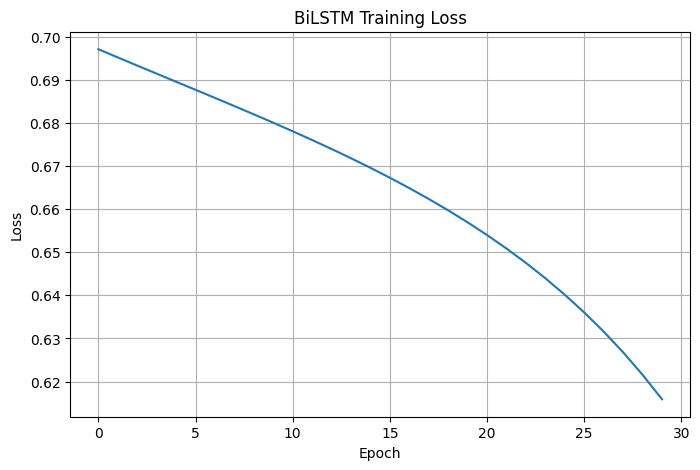

In [131]:
#Loss Curve
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.title("BiLSTM Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

In [132]:
#Architecture
print(model)

CustomBiLSTM(
  (forward_cell): CustomLSTMCell(
    (W_i): Linear(in_features=40, out_features=32, bias=True)
    (W_f): Linear(in_features=40, out_features=32, bias=True)
    (W_o): Linear(in_features=40, out_features=32, bias=True)
    (W_g): Linear(in_features=40, out_features=32, bias=True)
  )
  (backward_cell): CustomLSTMCell(
    (W_i): Linear(in_features=40, out_features=32, bias=True)
    (W_f): Linear(in_features=40, out_features=32, bias=True)
    (W_o): Linear(in_features=40, out_features=32, bias=True)
    (W_g): Linear(in_features=40, out_features=32, bias=True)
  )
  (fc): Linear(in_features=64, out_features=2, bias=True)
)
